In [1]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=64336735dd5b234fba3c4c3a2b2850ff357007470eadb17d10aef1ff371a30ee
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
from lifelines import KaplanMeierFitter
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [3]:
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
df = pd.read_csv(url)

T = df['YearsAtCompany']
E = df['Attrition'].apply(lambda x: 1 if x=='Yes' else 0)

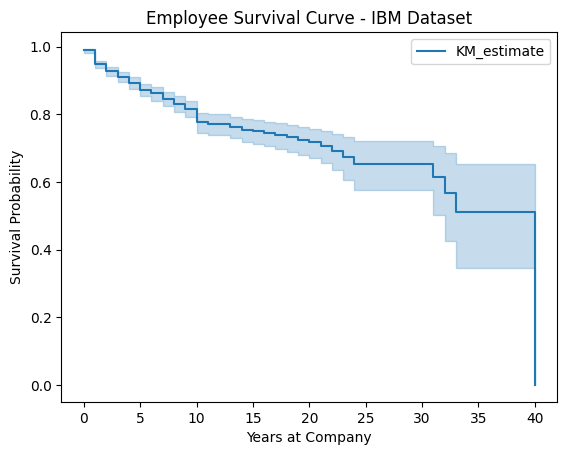

In [4]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)
kmf.plot_survival_function()
plt.title('Employee Survival Curve - IBM Dataset')
plt.xlabel('Years at Company')
plt.ylabel('Survival Probability')
plt.show()

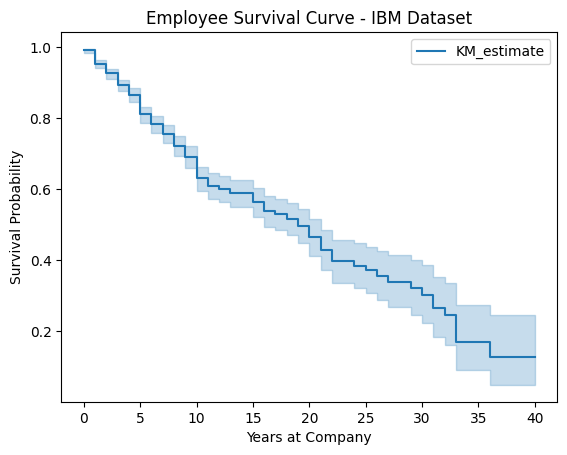

In [6]:
O = df['OverTime'].apply(lambda x: 1 if x=='Yes' else 0)
kmf.fit(T, event_observed=O)
kmf.plot_survival_function()
plt.title('Employee Survival Curve - IBM Dataset')
plt.xlabel('Years at Company')
plt.ylabel('Survival Probability')
plt.show()

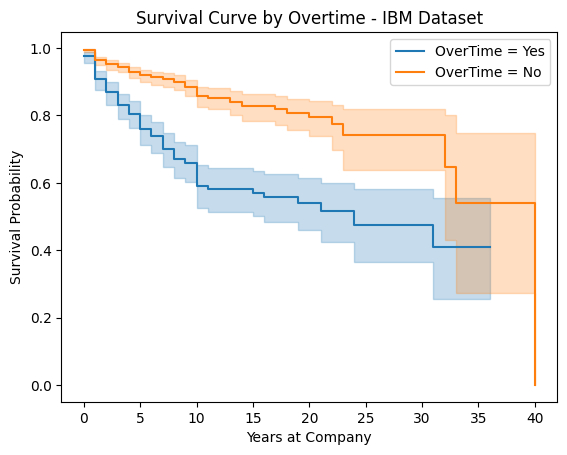

In [7]:
ax = plt.subplot(111)

kmf_ot = KaplanMeierFitter()
kmf_ot.fit(T[df['OverTime']=='Yes'],
           event_observed=E[df['OverTime']=='Yes'],
           label='OverTime = Yes')
kmf_ot.plot_survival_function(ax=ax)

kmf_no_ot = KaplanMeierFitter()
kmf_no_ot.fit(T[df['OverTime']=='No'],
              event_observed=E[df['OverTime']=='No'],
              label='OverTime = No')
kmf_no_ot.plot_survival_function(ax=ax)

plt.title('Survival Curve by Overtime - IBM Dataset')
plt.xlabel('Years at Company')
plt.ylabel('Survival Probability')
plt.show()

Employees working overtime are 30% less likely to remain with the company at the 10 year mark compared to those who don't. We recommend an immediate audit of overtime root causes — if it's understaffing, we accelerate hiring; if it's compensation, we review the overtime pay structure before we lose our most experienced engineers.